In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df=pd.read_csv("C:\\new project 11\\bike-repo\\data\\final_featured_data.csv")

In [5]:
df.head()

,displacement_cc,cylinder_count,engine_cycle,bore_mm,stroke_mm,fuel_system_type,fuel_injection,cooling_Air,cooling_Liquid,cooling_Oil & air,...,is_automatic,transmission_Belt (final drive),transmission_Chain (final drive),transmission_Shaft drive (cardan) (final drive),front_tyre_width,front_tyre_aspect,front_tyre_rim,rear_tyre_width,rear_tyre_aspect,rear_tyre_rim
0,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,80.0,90.0,21.0,110.0,80.0,18.0
1,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,130.0,80.0,17.0,130.0,70.0,17.0
2,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0
3,124.0,1.0,4.0,56.5,49.5,Carburettor,0,1,0,0,...,0,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0
4,233.0,1.0,4.0,69.0,62.5,Carburettor,0,0,0,1,...,0,0,1,0,70.0,100.0,19.0,100.0,100.0,17.0


In [9]:
df.drop(columns={"fuel_system_type"},inplace=True)

,displacement_cc,cylinder_count,engine_cycle,bore_mm,stroke_mm,fuel_system_type,fuel_injection,cooling_Air,cooling_Liquid,cooling_Oil & air,...,is_automatic,transmission_Belt (final drive),transmission_Chain (final drive),transmission_Shaft drive (cardan) (final drive),front_tyre_width,front_tyre_aspect,front_tyre_rim,rear_tyre_width,rear_tyre_aspect,rear_tyre_rim
0,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,80.0,90.0,21.0,110.0,80.0,18.0
1,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,130.0,80.0,17.0,130.0,70.0,17.0
2,49.9,1.0,2.0,40.0,39.7,Carburettor,0,0,1,0,...,0,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0
3,124.0,1.0,4.0,56.5,49.5,Carburettor,0,1,0,0,...,0,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0
4,233.0,1.0,4.0,69.0,62.5,Carburettor,0,0,0,1,...,0,0,1,0,70.0,100.0,19.0,100.0,100.0,17.0


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [12]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

c:\new project 11\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\new project 11\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\tgbst\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\tgbst\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\tgbst\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _

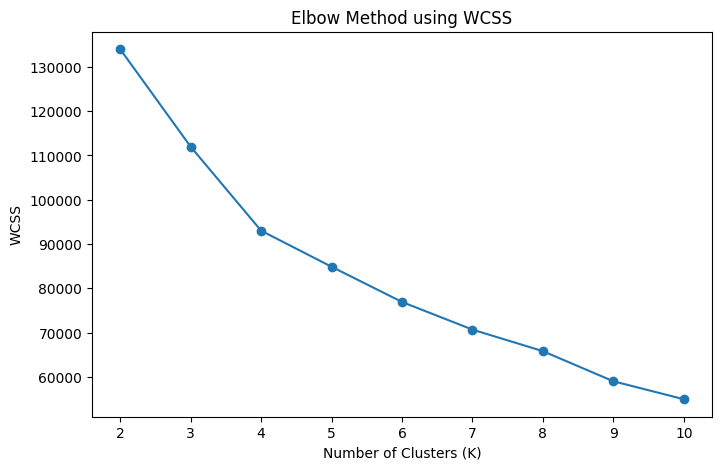

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method using WCSS")

plt.show()

In [14]:


kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [15]:
kmeans

KMeans(n_clusters=6, n_init=10, random_state=42)

In [16]:
df["Cluster"] = clusters

In [17]:
df.head()

,displacement_cc,cylinder_count,engine_cycle,bore_mm,stroke_mm,fuel_injection,cooling_Air,cooling_Liquid,cooling_Oil & air,gear_count,...,transmission_Belt (final drive),transmission_Chain (final drive),transmission_Shaft drive (cardan) (final drive),front_tyre_width,front_tyre_aspect,front_tyre_rim,rear_tyre_width,rear_tyre_aspect,rear_tyre_rim,Cluster
0,49.9,1.0,2.0,40.0,39.7,0,0,1,0,6.0,...,0,1,0,80.0,90.0,21.0,110.0,80.0,18.0,5
1,49.9,1.0,2.0,40.0,39.7,0,0,1,0,6.0,...,0,1,0,130.0,80.0,17.0,130.0,70.0,17.0,5
2,49.9,1.0,2.0,40.0,39.7,0,0,1,0,6.0,...,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0,5
3,124.0,1.0,4.0,56.5,49.5,0,1,0,0,5.0,...,0,1,0,100.0,80.0,17.0,130.0,70.0,17.0,3
4,233.0,1.0,4.0,69.0,62.5,0,0,0,1,5.0,...,0,1,0,70.0,100.0,19.0,100.0,100.0,17.0,3


In [18]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1797
1    1668
2     826
3    1343
4       2
5    2476
Name: count, dtype: int64

In [19]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.26161572495768476


In [20]:
df.groupby("Cluster").mean(numeric_only=True)

,displacement_cc,cylinder_count,engine_cycle,bore_mm,stroke_mm,fuel_injection,cooling_Air,cooling_Liquid,cooling_Oil & air,gear_count,is_automatic,transmission_Belt (final drive),transmission_Chain (final drive),transmission_Shaft drive (cardan) (final drive),front_tyre_width,front_tyre_aspect,front_tyre_rim,rear_tyre_width,rear_tyre_aspect,rear_tyre_rim
Cluster,,,,,,,,,,,,,,,,,,,,
0,1084.413022,2.263216,3.997774,88.579521,78.758876,0.843628,0.259321,0.651085,0.089594,5.535337,0.053979,0.279354,0.419588,0.301057,117.909850,79.193100,17.614914,171.597106,66.577629,16.393434
1,136.839868,1.002998,3.532374,53.457194,52.490887,0.518585,0.474221,0.509592,0.016187,3.308753,0.988010,0.959832,0.017386,0.022782,111.097722,75.511391,13.137890,123.288969,73.657074,12.822542
2,448.623971,1.085956,3.970944,82.930993,69.822760,0.561743,0.260291,0.694915,0.044794,5.088378,0.606538,0.290557,0.267554,0.441889,23.565375,7.661017,10.998789,23.328087,9.766344,10.685230
3,223.597543,1.134773,3.968727,61.816381,58.730454,0.344751,0.878630,0.000000,0.121370,4.921072,0.017126,0.023827,0.959792,0.016381,93.745346,86.429635,17.570365,117.148176,82.856292,16.383470
4,110.900000,1.000000,4.000000,50.000000,52.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,90.000000,90.000000,121841.000000,90.000000,100.000000,10.000000
5,274.041842,1.130856,3.328756,69.181704,57.013853,0.382876,0.000808,0.999192,0.000000,5.625202,0.011309,0.003231,0.996769,0.000000,94.161551,85.922859,19.207593,126.241519,79.768982,17.545032


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

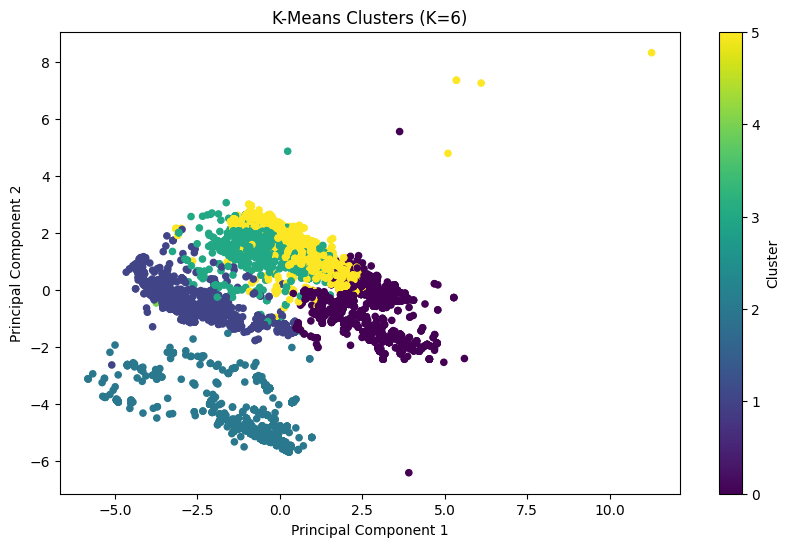

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (K=6)")

plt.colorbar(label="Cluster")

plt.show()